# Hybrid LSTM-Transformer 

Complete notebook for the project.

This notebook includes:
- data loading
- heavy hybrid LSTM-Transformer model
- training loop with training/validation timing
- test evaluation with test timing
- loss curve
- full single test trajectory plot
- scenario-wise MAE calculation

In [1]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import math
import matplotlib.pyplot as plt
import time
import os
import random
import h5py

In [2]:
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

BATCH_SIZE = 128
NUM_EPOCHS = 20
LEARNING_RATE = 1e-3
NUM_WORKERS = 0
WINDOW_SIZE = 200
STRIDE = 50
SAMPLING_RATE = 200
TEST_ROOT = "unseen_subjects_test_set"

Using device: cpu


In [3]:
X_train = np.load('X_train.npy')
y_train = np.load('y_train.npy')
X_val = np.load('X_val.npy')
y_val = np.load('y_val.npy')
X_test = np.load('X_test.npy')
y_test = np.load('y_test.npy')

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val:", X_val.shape, "y_val:", y_val.shape)
print("X_test:", X_test.shape, "y_test:", y_test.shape)

X_train: (198036, 200, 9) y_train: (198036, 2)
X_val: (82656, 200, 9) y_val: (82656, 2)
X_test: (76894, 200, 9) y_test: (76894, 2)


In [4]:
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32)

train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)
val_loader = DataLoader(
    TensorDataset(X_val_t, y_val_t),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)
test_loader = DataLoader(
    TensorDataset(X_test_t, y_test_t),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

In [5]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=500):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer("pe", pe)

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]


class HybridLSTMTransformer(nn.Module):
    def __init__(
        self,
        input_dim=9,
        lstm_hidden=128,
        lstm_layers=2,
        transformer_dim=128,
        num_heads=4,
        transformer_layers=2,
        ff_dim=256,
        lstm_dropout=0.3,
        transformer_dropout=0.2,
        fc_hidden=64,
        output_dim=2
    ):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=lstm_hidden,
            num_layers=lstm_layers,
            batch_first=True,
            dropout=lstm_dropout if lstm_layers > 1 else 0.0
        )

        self.proj = nn.Linear(lstm_hidden, transformer_dim)
        self.pos_encoder = PositionalEncoding(transformer_dim, max_len=200)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=transformer_dim,
            nhead=num_heads,
            dim_feedforward=ff_dim,
            dropout=transformer_dropout,
            batch_first=True,
            activation="relu"
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=transformer_layers)

        self.fc = nn.Sequential(
            nn.Linear(lstm_hidden + transformer_dim, fc_hidden),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(fc_hidden, output_dim)
        )

    def forward(self, x):
        lstm_out, (h_n, _) = self.lstm(x)
        lstm_last = h_n[-1]

        trans_in = self.proj(lstm_out)
        trans_in = self.pos_encoder(trans_in)
        trans_out = self.transformer(trans_in)
        trans_pool = trans_out.mean(dim=1)

        fused = torch.cat([lstm_last, trans_pool], dim=1)
        out = self.fc(fused)
        return out

In [6]:
model = HybridLSTMTransformer().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3, min_lr=1e-6
)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Trainable parameters:", total_params)

Trainable parameters: 501314


## Train the model

Run this section to train and save the best checkpoint as `best_hybrid_model_heavy.pth`.

In [7]:
num_epochs = NUM_EPOCHS
early_stop_patience = 7
best_val_loss = float('inf')
early_stop_counter = 0

train_losses = []
val_losses = []
train_epoch_times = []
val_epoch_times = []
lr_history = []

checkpoint_path = "best_hybrid_model_heavy.pth"
training_start_time = time.time()

for epoch in range(num_epochs):
    epoch_start_time = time.time()

    model.train()
    running_train_loss = 0.0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item() * xb.size(0)

    epoch_train_loss = running_train_loss / len(train_loader.dataset)
    train_losses.append(epoch_train_loss)

    train_time = time.time() - epoch_start_time
    train_epoch_times.append(train_time)

    model.eval()
    running_val_loss = 0.0
    val_start_time = time.time()

    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            preds = model(xb)
            loss = criterion(preds, yb)
            running_val_loss += loss.item() * xb.size(0)

    val_time = time.time() - val_start_time
    val_epoch_times.append(val_time)

    epoch_val_loss = running_val_loss / len(val_loader.dataset)
    val_losses.append(epoch_val_loss)

    scheduler.step(epoch_val_loss)
    current_lr = optimizer.param_groups[0]['lr']
    lr_history.append(current_lr)

    print(
        f"Epoch {epoch+1:02d} | "
        f"Train Loss: {epoch_train_loss:.6f} | "
        f"Val Loss: {epoch_val_loss:.6f} | "
        f"Train Time: {train_time:.2f}s | "
        f"Val Time: {val_time:.2f}s | "
        f"LR: {current_lr:.6f}"
    )

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        early_stop_counter = 0
        torch.save(model.state_dict(), checkpoint_path)
    else:
        early_stop_counter += 1
        if early_stop_counter >= early_stop_patience:
            print("Early stopping triggered.")
            break

total_training_time = time.time() - training_start_time
avg_val_time = np.mean(val_epoch_times)

print(f"\nTotal training time: {total_training_time:.2f} seconds")
print(f"Average validation time per epoch: {avg_val_time:.2f} seconds")
print("Best checkpoint saved to:", checkpoint_path)

Epoch 01 | Train Loss: 0.440534 | Val Loss: 0.407909 | Train Time: 1707.57s | Val Time: 173.95s | LR: 0.001000
Epoch 02 | Train Loss: 0.367571 | Val Loss: 0.399478 | Train Time: 1708.80s | Val Time: 169.05s | LR: 0.001000
Epoch 03 | Train Loss: 0.329624 | Val Loss: 0.382011 | Train Time: 1721.89s | Val Time: 180.23s | LR: 0.001000
Epoch 04 | Train Loss: 0.307697 | Val Loss: 0.378253 | Train Time: 1629.10s | Val Time: 167.31s | LR: 0.001000
Epoch 05 | Train Loss: 0.291988 | Val Loss: 0.382382 | Train Time: 1683.65s | Val Time: 165.20s | LR: 0.001000
Epoch 06 | Train Loss: 0.281083 | Val Loss: 0.392939 | Train Time: 1676.50s | Val Time: 167.07s | LR: 0.001000
Epoch 07 | Train Loss: 0.271574 | Val Loss: 0.387734 | Train Time: 1670.66s | Val Time: 153.06s | LR: 0.001000
Epoch 08 | Train Loss: 0.262317 | Val Loss: 0.386708 | Train Time: 1676.23s | Val Time: 170.02s | LR: 0.000500
Epoch 09 | Train Loss: 0.241223 | Val Loss: 0.390179 | Train Time: 1644.58s | Val Time: 163.14s | LR: 0.000500
E

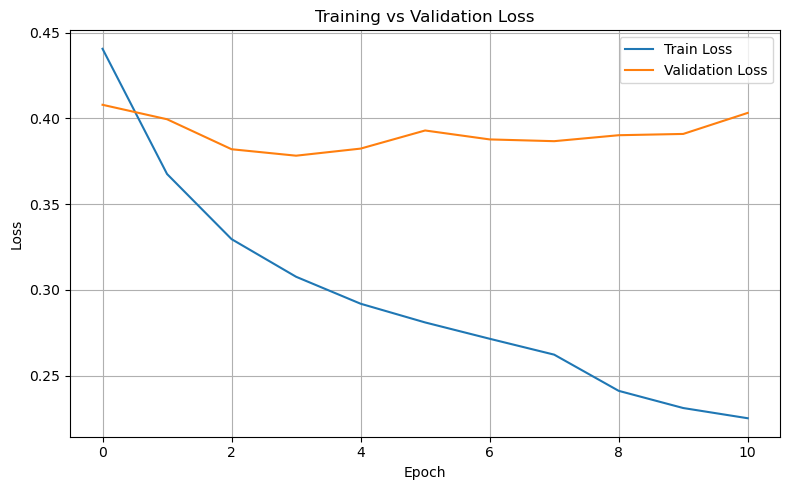

In [8]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("loss_curve_heavy.png", dpi=300, bbox_inches="tight")
plt.show()

In [16]:
def sincos_to_angle_deg(arr):
    angles = np.degrees(np.arctan2(arr[:, 0], arr[:, 1]))
    angles = (angles + 360) % 360
    return angles

def circular_error_deg(pred_deg, true_deg):
    diff = np.abs(pred_deg - true_deg)
    return np.minimum(diff, 360 - diff)

def circular_mae_rmse(pred_deg, true_deg):
    err = circular_error_deg(pred_deg, true_deg)
    mae = np.mean(err)
    rmse = np.sqrt(np.mean(err ** 2))
    return mae, rmse

## Final test evaluation

This uses the best saved checkpoint and reports MAE, RMSE, and test time.

In [17]:
model = HybridLSTMTransformer().to(device)
model.load_state_dict(torch.load(checkpoint_path, map_location=device))
model.eval()

all_preds = []
all_targets = []

test_start_time = time.time()

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        preds = model(xb).cpu().numpy()
        all_preds.append(preds)
        all_targets.append(yb.numpy())

test_time = time.time() - test_start_time

all_preds = np.concatenate(all_preds, axis=0)
all_targets = np.concatenate(all_targets, axis=0)

pred_deg = sincos_to_angle_deg(all_preds)
true_deg = sincos_to_angle_deg(all_targets)

mae, rmse = circular_mae_rmse(pred_deg, true_deg)

print(f"Test MAE:  {mae:.4f} degrees")
print(f"Test RMSE: {rmse:.4f} degrees")
print(f"Test time: {test_time:.2f} seconds")

Test MAE:  66.1114 degrees
Test RMSE: 82.8781 degrees
Test time: 134.65 seconds


## Full single unseen test trajectory plot

In [18]:
def create_windows(X, y, window_size=200, stride=50):
    X_windows = []
    y_windows = []
    for start in range(0, len(X) - window_size, stride):
        end = start + window_size
        X_windows.append(X[start:end])
        y_windows.append(y[end - 1])
    return np.array(X_windows), np.array(y_windows)

def load_sequence(seq_path):
    with h5py.File(seq_path, 'r') as f:
        acce = f['synced']['acce'][:]
        gyro = f['synced']['gyro'][:]
        magnet = f['synced']['magnet'][:]
        tango_pos = f['pose']['tango_pos'][:]

    dx = np.diff(tango_pos[:, 0])
    dy = np.diff(tango_pos[:, 1])
    heading = np.arctan2(dy, dx)

    acce = acce[1:]
    gyro = gyro[1:]
    magnet = magnet[1:]

    X = np.concatenate([acce, gyro, magnet], axis=1)
    y = np.column_stack([np.sin(heading), np.cos(heading)])
    return X, y

def sincos_to_deg(arr):
    deg = np.degrees(np.arctan2(arr[:, 0], arr[:, 1]))
    return (deg + 360) % 360

In [12]:
seq_name = sorted(os.listdir(TEST_ROOT))[0]
seq_path = os.path.join(TEST_ROOT, seq_name, "data.hdf5")

print("Using full test trajectory:", seq_name)

X_seq_raw, y_seq_raw = load_sequence(seq_path)
X_seq_win, y_seq_win = create_windows(X_seq_raw, y_seq_raw, WINDOW_SIZE, STRIDE)

mean = np.load("mean.npy")
std = np.load("std.npy")
X_seq_win = (X_seq_win - mean) / std

X_seq_t = torch.tensor(X_seq_win, dtype=torch.float32)
seq_loader = DataLoader(TensorDataset(X_seq_t), batch_size=BATCH_SIZE, shuffle=False)

model.eval()
seq_preds = []

with torch.no_grad():
    for (xb,) in seq_loader:
        xb = xb.to(device)
        out = model(xb).cpu().numpy()
        seq_preds.append(out)

seq_preds = np.concatenate(seq_preds, axis=0)

pred_deg_seq = sincos_to_deg(seq_preds)
true_deg_seq = sincos_to_deg(y_seq_win)
time_sec = (np.arange(len(pred_deg_seq)) * STRIDE + (WINDOW_SIZE - 1)) / SAMPLING_RATE

print("Number of windows in this full trajectory:", len(pred_deg_seq))

Using full test trajectory: a006_2
Number of windows in this full trajectory: 3475


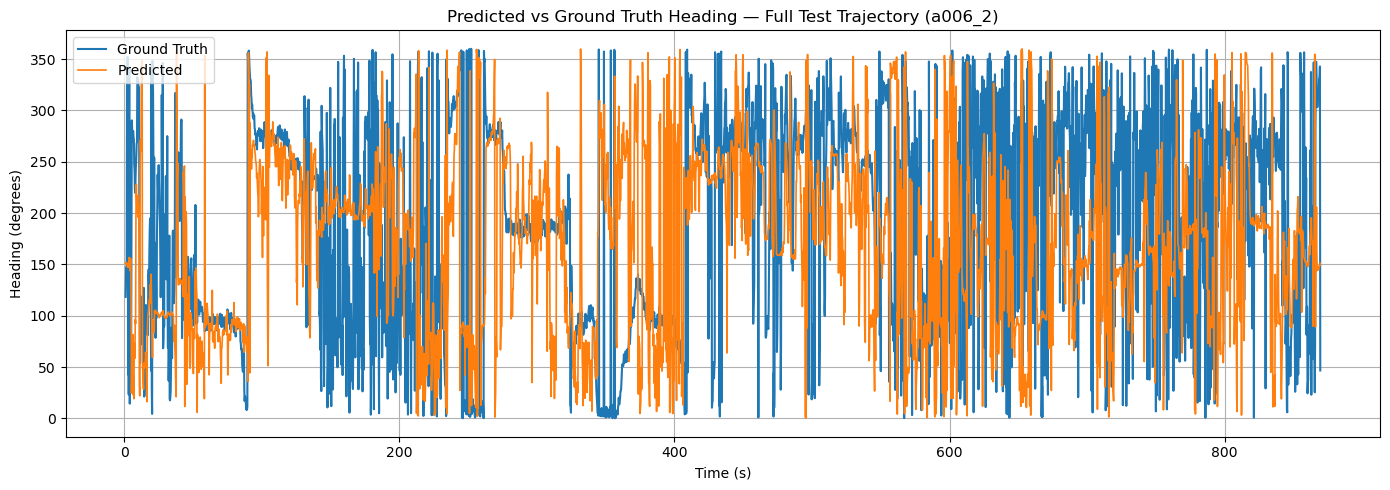

In [13]:
plt.figure(figsize=(14, 5))
plt.plot(time_sec, true_deg_seq, label="Ground Truth", linewidth=1.5)
plt.plot(time_sec, pred_deg_seq, label="Predicted", linewidth=1.2)
plt.xlabel("Time (s)")
plt.ylabel("Heading (degrees)")
plt.title(f"Predicted vs Ground Truth Heading — Full Test Trajectory ({seq_name})")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("pred_vs_true_full_trajectory_heavy.png", dpi=300, bbox_inches="tight")
plt.show()

## Scenario-wise MAE

Definitions used:
- Straight walking: heading change <= 10 degrees
- Sharp turns: heading change >= 45 degrees
- Short trajectories: below median number of windows
- Long trajectories: at or above median number of windows

In [14]:
seq_names = sorted([
    d for d in os.listdir(TEST_ROOT)
    if os.path.isdir(os.path.join(TEST_ROOT, d))
])

seq_lengths = {}

for seq_name in seq_names:
    seq_path = os.path.join(TEST_ROOT, seq_name, "data.hdf5")
    X_seq_raw, y_seq_raw = load_sequence(seq_path)
    X_seq_win, y_seq_win = create_windows(X_seq_raw, y_seq_raw, WINDOW_SIZE, STRIDE)
    seq_lengths[seq_name] = len(X_seq_win)

median_len = np.median(list(seq_lengths.values()))
print("Median trajectory length in windows:", median_len)

Median trajectory length in windows: 2551.5


In [15]:
mean = np.load("mean.npy")
std = np.load("std.npy")

straight_errors = []
sharp_errors = []
short_traj_errors = []
long_traj_errors = []

for seq_name in seq_names:
    seq_path = os.path.join(TEST_ROOT, seq_name, "data.hdf5")
    X_seq_raw, y_seq_raw = load_sequence(seq_path)
    X_seq_win, y_seq_win = create_windows(X_seq_raw, y_seq_raw, WINDOW_SIZE, STRIDE)

    X_seq_win = (X_seq_win - mean) / std

    X_seq_t = torch.tensor(X_seq_win, dtype=torch.float32)
    seq_loader = DataLoader(TensorDataset(X_seq_t), batch_size=BATCH_SIZE, shuffle=False)

    seq_preds = []
    model.eval()
    with torch.no_grad():
        for (xb,) in seq_loader:
            xb = xb.to(device)
            out = model(xb).cpu().numpy()
            seq_preds.append(out)

    seq_preds = np.concatenate(seq_preds, axis=0)

    pred_deg = sincos_to_deg(seq_preds)
    true_deg = sincos_to_deg(y_seq_win)
    err = circular_error_deg(pred_deg, true_deg)

    turn_amount = np.zeros_like(true_deg)
    turn_amount[1:] = circular_error_deg(true_deg[1:], true_deg[:-1])

    straight_mask = turn_amount <= 10.0
    sharp_mask = turn_amount >= 45.0

    is_short = len(X_seq_win) < median_len
    is_long = len(X_seq_win) >= median_len

    if np.any(straight_mask):
        straight_errors.extend(err[straight_mask])

    if np.any(sharp_mask):
        sharp_errors.extend(err[sharp_mask])

    if is_short:
        short_traj_errors.extend(err)

    if is_long:
        long_traj_errors.extend(err)

def safe_mae(x):
    return float(np.mean(x)) if len(x) > 0 else np.nan

print(f"Straight walking MAE: {safe_mae(straight_errors):.4f} degrees")
print(f"Sharp turns MAE: {safe_mae(sharp_errors):.4f} degrees")
print(f"Short trajectories MAE: {safe_mae(short_traj_errors):.4f} degrees")
print(f"Long trajectories MAE: {safe_mae(long_traj_errors):.4f} degrees")

Straight walking MAE: 58.7827 degrees
Sharp turns MAE: 89.8205 degrees
Short trajectories MAE: 64.8144 degrees
Long trajectories MAE: 66.9763 degrees
